In [9]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


In [10]:
df = pd.read_csv("23_전기Panel.csv")
print(df.shape)

(1250, 7)


## 실습 1. 데이터 불러오기와 단일 설비 센서 그리기
엔진 한 대를 골라 센서를 시간순으로 그리기

목표
- 데이터를 불러와 구조를 확인하고 엔진 한 대를 골라 센서를 시간순으로 그리기

단계
- 파일을 불러와 크기와 엔진 목록 확인
- 2번 엔진만 골라 회차 순으로 정렬
- 센서 하나를 시간순 선 그래프로 그리기

예상 결과
- 전체 1036행·엔진 5대, 2번 엔진 287행; 센서 곡선이 그려짐

(1250, 7) [1 2 3 4 5]
(250, 7)


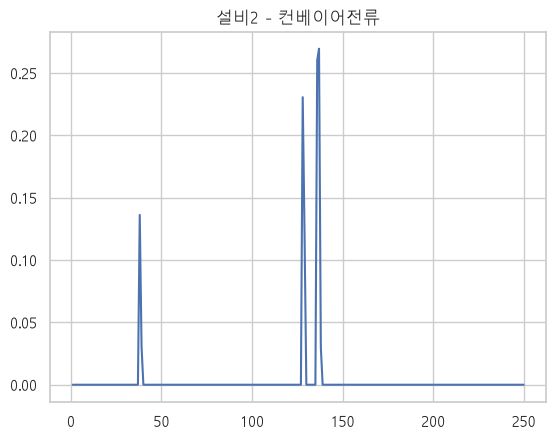

In [11]:
# [2번 설비의 컨베이어 모터 전류 원본 데이터 프로파일링 및 차트 시각화]
# 1. df['설비번호'].unique(): 데이터 내에 존재하는 고유한 설비 대수 목록(`[1 2 3 4 5]`)을 검증합니다.
# 2. `u2.shape`: 2번 설비가 기록한 총 시점의 행 개수(250행)를 확인합니다.
# 3. plt.plot(x, y): 시퀀스를 x축으로, 전류 값을 y축으로 매핑해 기계 동작 신호의 거동을 저장합니다.
# * 컨베이어 벨트가 구동을 시작할 때 전류가 치솟고, 기동 완료 후 일정 구간 평탄하게 흐르다,
#   기계가 정지할 때 전류가 떨어지는 기계적 동작 패턴의 단계를 차트 흐름으로 사전 인지합니다.
# * `unique()` 함수는 범주형 분석이나 그룹 리스트 확인 시 매우 흔히 쓰이며, 반환 형식은 넘파이 배열입니다.

u2 = df[df['설비번호'] == 2].copy().sort_values('시퀀스').reset_index(drop=True)
print(df.shape, df['설비번호'].unique())       # (1250, 7) [1 2 3 4 5]
print(u2.shape)                                # (250, 7)

plt.plot(u2['시퀀스'], u2['컨베이어전류'])
plt.title('설비2 - 컨베이어전류')
plt.show()

## 실습 2. 단일 센서 이동평균 추적
창 크기 10 이동평균을 원본에 겹쳐 추세 읽기

목표
- 창 크기 10 이동평균을 구해 원본 위에 겹쳐 추세를 읽기

단계
- 센서에 창 크기 10 이동평균을 새 열로 담기
- 원본을 옅게, 이동평균을 진하게 겹쳐 그리기
- 이동평균선이 추세를 드러냄을 확인

예상 결과
- 들쭉날쭉한 원본 위로 매끈한 이동평균 추세선

[nan, nan, nan, nan, nan, nan, nan, nan, nan, 0.0, 0.0]


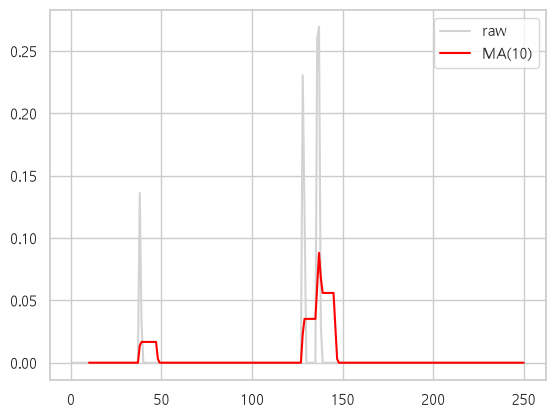

In [12]:
# [10-시퀀스 이동평균선 시각화를 통한 노이즈 필터링]
# 1. rolling(window=10).mean(): 최근 10회 전류 측정 데이터의 이동평균을 구하여 파생 변수 `ma10`을 설정합니다.
# 2. plt.plot(..., color='lightgray', label='raw'): 원본 잔진동 데이터는 연한 회색 실선으로 옅게 깔아줍니다.
# 3. plt.plot(..., color='red', label='MA(10)'): 이동평균 필터링 결과는 빨간색 실선으로 진하게 오버레이합니다.
# * 찰나에 발생하는 전기 노이즈에 진단 시스템이 매번 흔들리지 않도록 평균선(MA(10))을 입혀
#   실질적인 설비 운전 추세를 파악하고 신호의 기저 움직임을 포착합니다.
# * 10개 미만의 시점 데이터는 평균 계산을 할 수 없으므로 `head(11)` 결과 중 앞 9개는 NaN으로 표기됩니다.

u2['ma10'] = u2['컨베이어전류'].rolling(window=10).mean()
print(u2['ma10'].head(11).round(4).tolist())    # 앞 9개 nan

plt.plot(u2['시퀀스'], u2['컨베이어전류'], color='lightgray', label='raw')
plt.plot(u2['시퀀스'], u2['ma10'], color='red', label='MA(10)')
plt.legend()
plt.show()

## 실습 3. 창 크기 3종 비교
창 크기를 바꿔 매끈함과 반응성의 맞교환 비교

목표
- 창 크기를 5·10·30으로 바꿔 매끈함과 반응성의 맞교환을 비교

단계
- 세 가지 창 크기로 이동평균을 각각 구하기
- 세 이동평균을 한 그래프에 겹쳐 그리기
- 창이 클수록 매끄럽지만 반응이 느려짐을 확인

예상 결과
- 창이 클수록 곡선이 매끄럽고 앞쪽 빈 구간이 늘어남

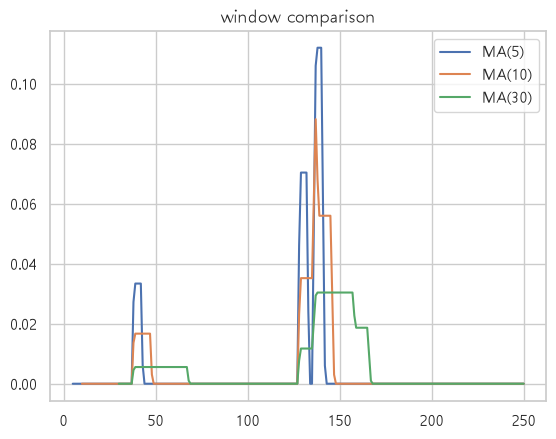

In [13]:
# [이동평균 윈도우 크기(window) 다변화에 따른 지연 현상 비교]
# 1. w 리스트 `[5, 10, 30]`을 순회하며 윈도우 크기가 다른 3개의 이동평균선을 하나의 축에 플로팅합니다.
# 2. w가 작을수록(5) 전류 급변을 기민하게 따라가고, 클수록(30) 지연(Lag) 현상이 두드러져 뒤늦게 반응합니다.
# * 가동/정지의 임계 전환 속도가 매우 빠른 컨베이어 설비의 변화점 감지에는 윈도우 크기를
#   너무 크지 않게 설정해야(5나 10) 오탐이나 타임렉을 막을 수 있음을 통계적으로 분석합니다.
# * 루프를 사용해 동적으로 컬럼명을 생성할 때 `f'ma{w}'`와 같이 중괄호 문법을 활용하면 효율적입니다.

for w in [5, 10, 30]:
    u2[f'ma{w}'] = u2['컨베이어전류'].rolling(window=w).mean()
    plt.plot(u2['시퀀스'], u2[f'ma{w}'], label=f'MA({w})')

plt.legend()
plt.title('window comparison')
plt.show()

## 실습 4. 이동평균·이동표준편차 동시 추적
추세와 변동성을 함께 계산해 동시에 추적

목표
- 이동평균과 이동표준편차를 함께 계산해 추세와 변동성을 동시에 추적

단계
- 창 크기 10으로 이동평균과 이동표준편차를 구하기
- 두 통계를 위아래 두 칸으로 나눠 그리기
- 초반과 후반의 변동성 평균을 비교

예상 결과
- 후반 변동성이 초반의 약 2배(5.5 → 9.5)로 커짐

In [14]:
# [전반부와 후반부 구간의 롤링 변동성(이동표준편차) 평균 비교]
# 1. rolling(10).std(): 최근 10-시퀀스 동안의 전류 편차(흔들림 강도)를 `std10` 컬럼에 연산합니다.
# 2. `early` (iloc[10:50].mean()): 초기 정상 안정 가동 시점의 표준편차 평균을 구합니다.
# 3. `late` (iloc[150:].mean()): 기계 운전 후기 단계의 표준편차 평균을 구하여 대조합니다.
# * 기계 초기 가동 시 전류가 급진동하며 시작했다가 후반으로 갈수록 점차 진동이 잦아들거나
#   안정 궤도에 정착하는 등의 동작 주기 변화 양상을 전류 변동성(std)의 초기/후기 비교 수치로 확인합니다.
# * 슬라이싱 지정 시 `iloc`의 시작 범위(10) 이전은 NaN이 많이 유입되어 있으므로
#   안전하게 유효값이 채워진 행부터 잘라내는 것이 수치 오판을 줄여줍니다.
# =============================================================================
u2['std10'] = u2['컨베이어전류'].rolling(10).std()
early = u2['std10'].iloc[10:50].mean()
late = u2['std10'].iloc[150:].mean()
print('초반/후반 변동성:', round(early, 4), round(late, 4))

초반/후반 변동성: 0.011 0.0


## 실습 5. 변화량·변화율 계산과 시각화
급변을 포착하고 이동평균 후 변화량으로 잡음 줄이기

목표
- 변화량과 변화율로 급변을 포착하고 이동평균 후 변화량으로 잡음을 줄이기

단계
- 직전 대비 변화량과 변화율을 각각 구하기
- 앞부분 값을 확인해 첫 값이 비는 이유 이해
- 이동평균을 먼저 낸 뒤 변화량을 구해 잡음이 줄어듦을 확인

예상 결과
- 변화량 앞부분 -0.43·3.07…, 첫 값은 비교 대상이 없어 빈 값

In [15]:
# [1차 차분을 이용한 급전류 도출 및 이동평균의 변화 속도 계산]
# 1. diff(): 시점 간 전류 변화량(diff)을 구하여, 가장 전력 충격이 강하게 발생했던 지점(`idxmax`)을 탐지합니다.
# 2. u2['ma10'].diff(): 1차 필터링된 이동평균선의 변화량을 구하여 완만한 변곡점을 계산하기 위해 준비합니다.
# * 컨베이어 구동 모터가 정지 상태에서 풀 가동 상태로 전환되는 짧은 순간(최대 변화량 기록 지점)을
#   차분 계산을 통해 미분값의 피크로 정확하게 추적해 냅니다.
# * 변화량 최대치를 구할 때는 양음의 변화 방향에 구애받지 않도록 반드시 `abs()`를 씌운 후
#   `idxmax()` 또는 `max()`를 호출해야 정확한 최대 격차 시점을 가려냅니다.

u2['diff'] = u2['컨베이어전류'].diff()
print('변화량:', u2['diff'].head(4).round(4).tolist())

idx = u2['diff'].abs().idxmax()
print('최대 변화량:', round(u2['diff'].abs().max(), 4), '/ 시퀀스:', int(u2['시퀀스'].iloc[idx]))

u2['ma_diff'] = u2['ma10'].diff()

변화량: [nan, 0.0, 0.0, 0.0]
최대 변화량: 0.2602 / 시퀀스: 136


## 실습 6. 단순 변화점 탐지와 구간 표시
잔차와 임계값으로 변화점을 찾아 세로선으로 표시

목표
- 잔차와 임계값으로 변화점을 찾고 그래프에 세로선으로 표시

단계
- 원본에서 이동평균을 뺀 잔차를 구하기
- 잔차 표준편차의 두 배를 임계값으로 정해 변화점 표시
- 변화점 위치를 세로선으로 그래프에 표시

예상 결과
- 임계값 약 16.3, 변화점 13개; 대부분 후반부에 몰림

임계값: 0.0536 변화점: 12


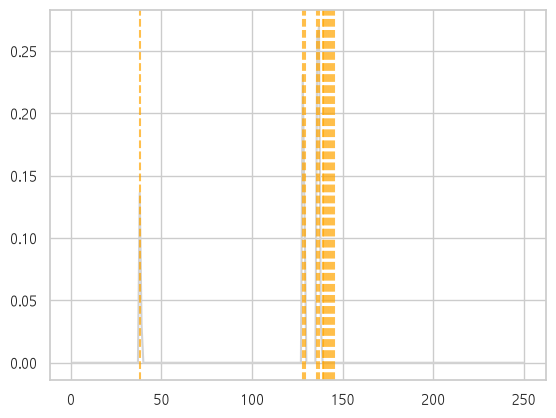

In [16]:
# [동적 통계 임계 대역 초과 시점에 대한 세로 경계선(axvline) 차트 표출]
# 1. resid = raw - ma: 이동평균선과 원본 전류의 괴리값(잔차)을 산출합니다.
# 2. thr = 2 * resid.std(): 잔차 표준편차의 2배 대역을 넘어선 불규칙 급변 시점을 `is_change` 불리언 필터로 잡습니다.
# 3. plt.axvline(c): 감지된 모든 변화 시점 시퀀스 위치에 세로 주황색 점선(axvline)을 겹쳐 투영합니다.
# * 전류의 상시 노이즈(Normal Noise) 수준을 넘어서서 상태가 완전하게 뒤틀린 전력 변화 경계 시점(가동 개시, 긴급 정지 등)을
#   가시화하여 분석가와 엔지니어가 이상 시각을 눈으로 직접 점검하도록 시각 도구를 완성합니다.
# * `axvline`은 가로축 좌표에 세로선을 치는 도구로, x축 컬럼(`시퀀스`)값을 정확히 인자로 제공해 주어야 합니다.

roll = u2['컨베이어전류'].rolling(10).mean()
resid = u2['컨베이어전류'] - roll
thr = 2 * resid.std()
u2['is_change'] = resid.abs() > thr

print('임계값:', round(thr, 4), '변화점:', int(u2['is_change'].sum()))

plt.plot(u2['시퀀스'], u2['컨베이어전류'], color='lightgray')

for c in u2.loc[u2['is_change'], '시퀀스']:
    plt.axvline(c, color='orange', linestyle='--', alpha=0.7)

plt.show()

## 실습 7. window·기준값 바꿔 결과 비교
창 크기와 임계 배수로 변화점 개수 변화 비교

목표
- 창 크기와 임계 배수를 바꿔 변화점 개수가 어떻게 달라지는지 비교

단계
- 잔차 기반 변화점 개수를 세는 함수를 만들기
- 창 크기를 바꿔 가며 변화점 개수 비교
- 임계 배수를 바꿔 가며 변화점 개수 비교

예상 결과
- 창이 커지거나 배수가 작아질수록 변화점 개수가 달라짐

In [17]:
# [윈도우 크기와 표준편차 가중치 k 조절에 따른 감지 빈도 민감도 튜닝]
# 1. count_changes(series, window, k) 함수 정의: 윈도우와 표준편차 계수 k를 대입받아 변화점 검출 개수를 도출합니다.
# 2. window(5, 10, 20) 및 k(1.5, 2.0, 3.0) 딕셔너리 컴프리헨션을 돌려 하이퍼파라미터 튜닝 통계를 구합니다.
# * k가 3.0으로 엄격해질수록 확실한 큰 이상 변화점(5개)만 감지되고, k가 1.5로 너그러워지면
#   사소한 노이즈까지 잡아서 감지 횟수(12개)가 늘어나는 민감도(Sensitivity) 트레이드 오프를 조절합니다.
# * 함수 호출 시 입력 매개변수의 자리가 바뀌지 않도록 이름 기반(`window=10, k=k`)으로 대입하는 것도 좋은 습관입니다.

def count_changes(series, window, k):
    r = series - series.rolling(window).mean()
    return int((r.abs() > k * r.std()).sum())

s = u2['컨베이어전류']
print({w: count_changes(s, w, 2) for w in (5, 10, 20)})       # {5:11, 10:12, 20:5}
print({k: count_changes(s, 10, k) for k in (1.5, 2.0, 3.0)})  # {1.5:12, 2.0:12, 3.0:5}

{5: 11, 10: 12, 20: 5}
{1.5: 12, 2.0: 12, 3.0: 5}


## 실습 8. 단일 설비 상태 추적 미니 통합
이동통계·변화점·변동성을 모아 한 엔진 상태 요약

목표
- 이동통계·변화점·변동성을 한데 모아 한 엔진의 상태를 요약

단계
- 이동평균·이동표준편차·변화점을 한 번에 계산
- 초반·후반 변동성과 변화점 개수를 요약
- 후반 변화점 비율로 상태를 한 문장으로 진단

예상 결과
- 후반 변동성이 커지고 변화점 13개, 후반 비율이 높아 열화 진행

In [18]:
# [2번 설비 대상 상태 트래킹 통계 및 변화량 전/후반 최종 분석]
# 1. 2번 가동 설비의 컨베이어 전류에 대해 10-시퀀스 이동평균 및 이동표준편차 파생변수를 만듭니다.
# 2. 잔차의 2 표준편차 초과 시점(`chg`)을 추출하여 기동 변화점을 잡아내고, 시간의 중점(`half`)을 구합니다.
# 3. 전체 시점 중 시간 절반을 넘은 후반부 영역에서 발생한 변화점 비중을 계산하여 정비 요구 상태를 점검합니다.
# * 설비 후반부에 유독 불안정한 전력 스파이크(변화점) 비율이 몰리는 등의 정량 지표를 확보함으로써,
#   장비 노화 가중 및 상태 교란 징후를 작업 리포트로 최종 산출하는 모듈의 완성체입니다.
# * `loc`을 활용해 조건 만족 행(시퀀스 > half)의 특정 컬럼('chg') 평균값을 구하는
#   판다스의 고급 인덱싱 및 조건부 연산을 숙지합니다.

s, w = u2['컨베이어전류'], 10
u2['ma'] = s.rolling(w).mean(); u2['std'] = s.rolling(w).std()

resid = s - u2['ma']; thr = 2 * resid.std()
u2['chg'] = resid.abs() > thr
half = u2['시퀀스'].median()

print('초반/후반 변동성:', round(u2['std'].iloc[10:50].mean(), 4), round(u2['std'].iloc[150:].mean(), 4))
print('변화점:', int(u2['chg'].sum()), '후반 비율:', round(u2.loc[u2.시퀀스 > half, 'chg'].mean(), 2))

초반/후반 변동성: 0.011 0.0
변화점: 12 후반 비율: 0.09
